Вариант задания определяется согласно предложенному скрипту:

In [3]:
surname = "Новиков"  # Ваша фамилия

alph = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
w = [4, 42, 21, 21, 55,  1, 44, 26, 18, 3, 38, 26, 18, 12,  3, 49, 45,
        7, 42, 9,  4,  3, 36, 33, 31, 29,  5, 4,  4, 19, 21, 27, 33]
d = dict(zip(alph, w))
variant =  sum([d[el] for el in surname.lower()]) % 40 + 1

print("Задание № 2. Вариант: ", variant % 2 + 1)
print("Задание № 3. Вариант: ", variant % 3 + 1 )

Задание № 2. Вариант:  2
Задание № 3. Вариант:  2


# Задача 1. Реализация собственных классов и функций

## 1 пункт
Реализовать класс, предназначенный для оценки параметров линейной регрессии с регуляризацией совместимый с `sklearn`. 

Передаваемые параметры: 
1. коэффициент регуляризации (*alpha*). 

Использовать **метод наименьших квадратов с регуляризацией**.

Подключаем необходимые библиотеки:

In [15]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

Определим класс, реализующий ридж-регрессию (*формула известна*).

Класс будет оценивать параметры линейной регрессии с заданной регуляризацией.

Родительским для нашего класса будут: 
* `BaseEstimator` - базовый для всех моделей в sklearn
* `RegressorMixin` - это добавка, которая говорит: "модель — это регрессор"

In [16]:
class CustomLinearRegression(BaseEstimator, RegressorMixin):
    
    def __init__(self, alpha=1.0, method='ridge'):
        self.alpha = alpha
        self.method = method
    
    def fit(self, X, y):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = X_b.shape[1]
        I = np.eye(n_features)
        I[0, 0] = 0
        self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.coef_

Теперь проверим написаный класс на практике. 
Для этого подготовим данные, с которыми будем работать

In [31]:
def generate_data(n=100, start_x=4, length_x=8, mu=0, sigma=0.5):
    """Генерация данных."""
    from scipy import stats
    f = lambda x: 2 + 0.3*x
    x = stats.uniform.rvs(size=n, loc=start_x, scale=length_x, random_state=1)
    e = stats.norm.rvs(size=n, loc=mu, scale=sigma, random_state=1)
    return x.reshape(-1,1), f(x) + e

In [32]:
def plot_regression(X, y, model=None):
    """
    Функция для отображения наблюдений и линии регрессии.

    Parameters:
    X : numpy array, shape (n_samples, n_features)
        Входные данные (матрица признаков).
    y : numpy array, shape (n_samples,)
        Целевые значения (метки).
    model : объект модели, который имеет метод predict
        Модель, предсказывающая значения для регрессионной линии.
    """
    plt.figure(2, figsize=[4, 4])
    
    xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 2).reshape(-1, 1)

    plt.subplot(1, 1, 1)
    plt.scatter(X[:, 0], y, color="green", label="Sample", zorder=2)
    if model:
        plt.plot(xx, model.predict(xx), "-", color="grey", label="Regression")
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.legend()
    plt.grid(True)
    plt.show()

In [35]:
X, y = generate_data()

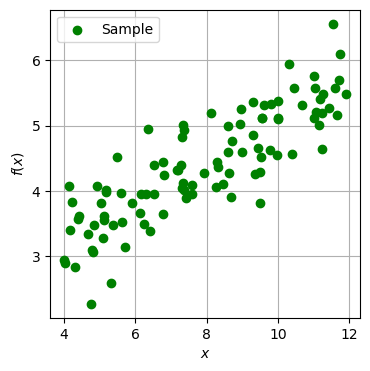

In [36]:
# Отображение наблюдений
plot_regression(X, y)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
# Разбиение данных на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
X_train[:5], y_train[:5]

(array([[6.24355194],
        [9.53501691],
        [6.15942313],
        [5.69302493],
        [6.52412505]]),
 array([3.49948643, 4.52488201, 3.9469768 , 3.13664838, 3.95090521]))

In [39]:
model = CustomLinearRegression()

In [40]:
# Обучение
model.fit(X_train, y_train)
model.coef_

array([1.90471493, 0.30801062])

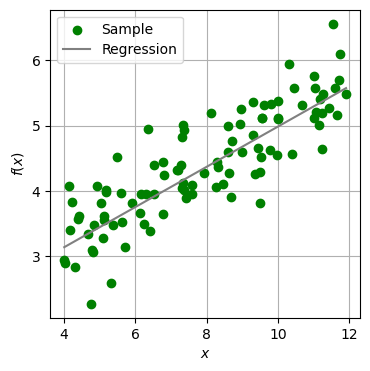

In [42]:
# Отображение наблюдений и линии регрессии
plot_regression(X, y, model)

In [43]:
model.score(X_test, y_test)

0.7111923560425134

как видно, получена точность 70%

## 2 пункт

Реализовать класс, предназначенный для для стандартизации признаков в виде трансформации совместимый с `sklearn`. 

Передаваемые параметры: 
1. has_bias (содержит ли матрица вектор единиц), 
2. apply_mean (производить ли центровку)

In [45]:
class CustomStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, has_bias=False, apply_mean=True):
        self.has_bias = has_bias
        self.apply_mean = apply_mean

    def fit(self, X, y=None):
        X = check_array(X)

        start_col = 1 if self.has_bias else 0
        self.mean_ = np.zeros(X.shape[1])
        self.std_ = np.ones(X.shape[1])

        if self.apply_mean:
            self.mean_[start_col:] = np.mean(X[:, start_col:], axis=0)
        self.std_[start_col:] = np.std(X[:, start_col:], axis=0, ddof=0)

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "std_"])
        X = check_array(X)

        X_scaled = (X - self.mean_) / self.std_
        if self.has_bias:
            X_scaled[:, 0] = X[:, 0]  # не трогаем bias-столбец

        return X_scaled

Создадим экземпляр нового класса:

In [55]:
scaler = CustomStandardScaler()

In [59]:
# Стандартизируем данные
scaler.fit(X)
X_scaled = scaler.transform(X)
# Отображение X
print("Исходные данные X:")
print(X[:5])

print("\nСтандартизированные данные X_scaled:")
print(X_scaled[:5])

Исходные данные X:
[[7.33617604]
 [9.76259595]
 [4.000915  ]
 [6.41866058]
 [5.17404713]]

Стандартизированные данные X_scaled:
[[-0.23388437]
 [ 0.79634961]
 [-1.65000333]
 [-0.62345239]
 [-1.15190299]]
